# 1.0 - Data Understanding & Cleaning
**Projeto:** Telco Customer Churn  
**Milestone:** M1/M2  
**Autores:** Salvador Cabeças & Vasco Coelho  
**Data:** Fevereiro 2026  

### Objetivo:
Este notebook documenta o carregamento, a auditoria de tipos e o tratamento inicial dos dados, garantindo que o dataset está tecnicamente apto para a análise estatística avançada.

In [1]:
import os

# Lista de pastas que o teu projeto precisa
pastas = ['reports/figures', 'data/raw', 'data/processed', 'models']

# Criar cada pasta automaticamente se ela não existir
for pasta in pastas:
    os.makedirs(pasta, exist_ok=True)
    print(f"✅ Pasta verificada/criada: {pasta}")

✅ Pasta verificada/criada: reports/figures
✅ Pasta verificada/criada: data/raw
✅ Pasta verificada/criada: data/processed
✅ Pasta verificada/criada: models


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração de estilo global
sns.set_theme(style="whitegrid")

# Carregar dados
path = '/kaggle/input/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv'
df = pd.read_csv(path)

print("--- Visualização Inicial (Head) ---")
display(df.head())

--- Visualização Inicial (Head) ---


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### Auditoria de Qualidade (Pré-Tratamento)
Antes de qualquer transformação, verificamos a existência de valores nulos reais e "nulos invisíveis" (espaços em branco lidos como texto válido pelo Pandas).

In [3]:
# ─── AUDITORIA PRÉ-TRATAMENTO ────────────────────────────────
# Semana 3-4 | Fase CRISP-DM: Data Understanding
# Justificação: identificar problemas ANTES de os corrigir

# 1. Informação geral sobre tipos e nulos
print("--- Info Geral (tipos e nulos) ---")
df.info()

# 2. Investigação de 'nulos invisíveis' em TotalCharges
# O Pandas leu espaços em branco como texto válido — precisamos de os expor
missing_spaces = df[df['TotalCharges'].str.strip() == '']
print(f"\n📌 Linhas com espaços em branco em TotalCharges: {len(missing_spaces)}")
print("Prova de Negócio: todos têm tenure=0 (novos contratos sem faturação acumulada)")
display(missing_spaces[['customerID', 'tenure', 'TotalCharges']])
print("🔧 Próximo passo: converter TotalCharges para float e imputar com 0.0")

--- Info Geral (tipos e nulos) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  Paperle

,customerID,tenure,TotalCharges
488,4472-LVYGI,0,
753,3115-CZMZD,0,
936,5709-LVOEQ,0,
1082,4367-NUYAO,0,
1340,1371-DWPAZ,0,
3331,7644-OMVMY,0,
3826,3213-VVOLG,0,
4380,2520-SGTTA,0,
5218,2923-ARZLG,0,
6670,4075-WKNIU,0,


🔧 Próximo passo: converter TotalCharges para float e imputar com 0.0


In [4]:
# Estatística descritiva inicial (antes do tratamento)
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.162147,0.368612,0.00,0.0,0.00,0.00,1.00
tenure,7043.0,32.371149,24.559481,0.00,9.0,29.00,55.00,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.5,70.35,89.85,118.75


### Data Preparation: Transformação de Variáveis
Para permitir a análise estatística (M2) e a modelação (M3), realizamos as seguintes correções:
1. Converter `TotalCharges` para float (forçando NaN nos espaços vazios) e imputar com `0.0`.
2. Codificar a variável alvo `Churn` de forma binária (0 e 1).
3. Otimizar variáveis categóricas (tipo `category`) para poupar memória.
4. Confirmar integridade final do dataset.

In [5]:
# ─── DATA PREPARATION & TIPIFICAÇÃO ─────────────────────────
# Semana 3-4 | Fase CRISP-DM: Data Preparation
# Justificação: garantir que os tipos de dados refletem a realidade do negócio

# 1. Conversão de TotalCharges e tratamento dos 11 nulos
# errors='coerce' converte espaços em branco para NaN; fillna(0.0) imputa clientes com tenure=0
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(0.0)

# 2. Mapeamento da Target (Churn) para Numérico
# Essencial para correlações e algoritmos de ML
if df['Churn'].dtype == 'O':
    df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0}).astype('int64')

# 3. Tipificação Categórica (otimização de memória)
cat_cols = [
    'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
    'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
    'PaperlessBilling', 'PaymentMethod', 'SeniorCitizen'
]
for col in cat_cols:
    df[col] = df[col].astype('category')

# 4. Verificação de integridade pós-tratamento
print("✅ Transformações concluídas!")
print(f"   Nulos em TotalCharges: {df['TotalCharges'].isnull().sum()} (esperado: 0)")
print(f"   Linhas totais preservadas: {len(df)} (esperado: 7043)")

# Auditoria completa pós-tratamento
null_summary = pd.DataFrame({
    'Nulos Reais': df.isnull().sum(),
    'Percentagem (%)': (df.isnull().sum() / len(df)) * 100
})
print("\n--- Auditoria Completa Pós-Tratamento ---")
display(null_summary.sort_values(by='Percentagem (%)', ascending=False))
print("📌 Insight: 0 nulos em todas as colunas — dataset pronto para análise.")

✅ Transformações concluídas!
   Nulos em TotalCharges: 0 (esperado: 0)
   Linhas totais preservadas: 7043 (esperado: 7043)

--- Auditoria Completa Pós-Tratamento ---


,Nulos Reais,Percentagem (%)
customerID,0,0.0
gender,0,0.0
SeniorCitizen,0,0.0
Partner,0,0.0
Dependents,0,0.0
tenure,0,0.0
PhoneService,0,0.0
MultipleLines,0,0.0
InternetService,0,0.0
OnlineSecurity,0,0.0


📌 Insight: 0 nulos em todas as colunas — dataset pronto para análise.


In [6]:
print("--- Estatística das Categóricas (pós-tipificação) ---")
display(df.describe(include=['category', 'object']).T)

print("\n--- Estatística das Numéricas (pós-tratamento) ---")
display(df.describe().T)

--- Estatística das Categóricas (pós-tipificação) ---


,count,unique,top,freq
customerID,7043,7043,3186-AJIEK,1
gender,7043,2,Male,3555
SeniorCitizen,7043,2,0,5901
Partner,7043,2,No,3641
Dependents,7043,2,No,4933
PhoneService,7043,2,Yes,6361
MultipleLines,7043,3,No,3390
InternetService,7043,3,Fiber optic,3096
OnlineSecurity,7043,3,No,3498
OnlineBackup,7043,3,No,3088



--- Estatística das Numéricas (pós-tratamento) ---


,count,mean,std,min,25%,50%,75%,max
tenure,7043.0,32.371149,24.559481,0.00,9.00,29.00,55.00,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.50,70.35,89.85,118.75
TotalCharges,7043.0,2279.734304,2266.794470,0.00,398.55,1394.55,3786.60,8684.80
Churn,7043.0,0.265370,0.441561,0.00,0.00,0.00,1.00,1.00


## 1.0 - Análise da Variável Alvo (Churn)

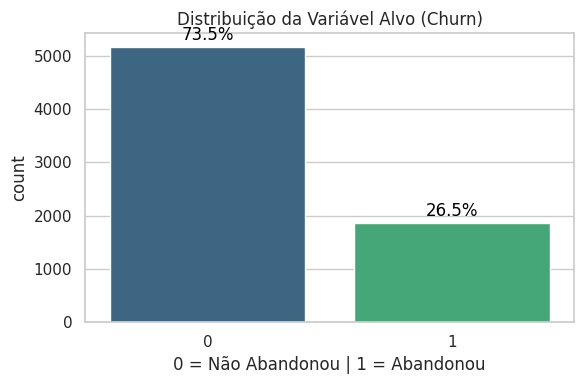

📌 Insight: Desequilíbrio de classes (73.5% vs 26.5%) — usar Recall e F1-Score, não Accuracy.
🔧 Próximo passo: análise univariada das variáveis numéricas.


In [7]:
# ─── DISTRIBUIÇÃO DA VARIÁVEL ALVO ──────────────────────────
# Semana 4 | Fase CRISP-DM: Data Understanding
# Justificação: avaliar o desequilíbrio de classes antes de modelar

plt.figure(figsize=(6, 4))
ax = sns.countplot(x='Churn', data=df, hue='Churn', palette='viridis', legend=False)
plt.title('Distribuição da Variável Alvo (Churn)')
plt.xlabel('0 = Não Abandonou | 1 = Abandonou')

total = len(df)
for p in ax.patches:
    height = p.get_height()
    percentage = f'{100 * height / total:.1f}%'
    ax.annotate(percentage, (p.get_x() + p.get_width() / 2., height),
                ha='center', va='baseline', fontsize=12, color='black',
                xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.savefig('reports/figures/01_churn_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("📌 Insight: Desequilíbrio de classes (73.5% vs 26.5%) — usar Recall e F1-Score, não Accuracy.")
print("🔧 Próximo passo: análise univariada das variáveis numéricas.")

### Análise da Variável Alvo (Churn)
**Insight Técnico:** Observamos um desequilíbrio de classes (**Imbalanced Data**), com a taxa de abandono fixada em **26.5%**.  
**Implicação de Negócio:** Um modelo "preguiçoso" que preveja sempre "Não Churn" teria 73.5% de *Accuracy*, mas falharia 100% no objetivo de retenção.  
**Decisão:** Focaremos em métricas de **Recall** e **F1-Score** para garantir que identificamos a classe minoritária.

## 2.0 - Distribuição de Variáveis Numéricas

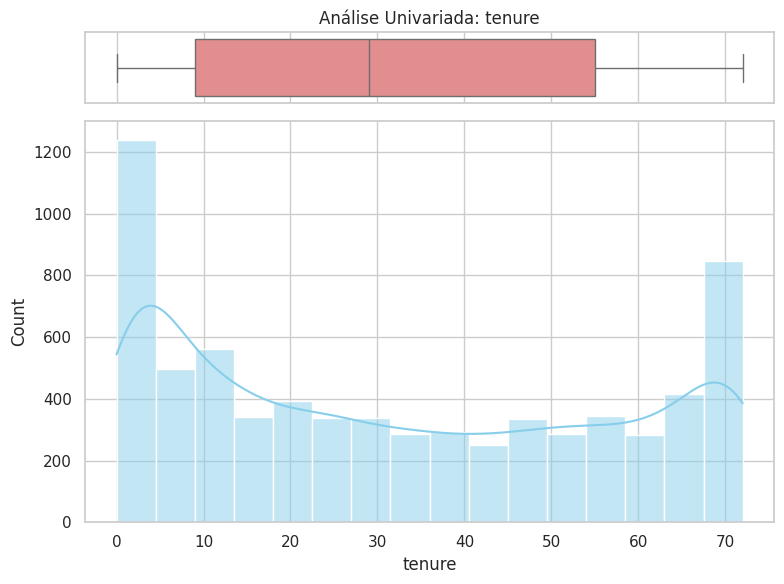

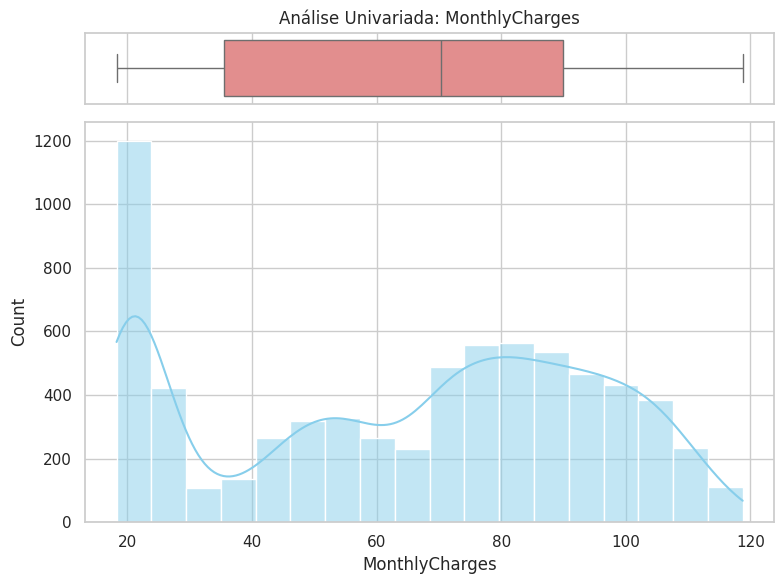

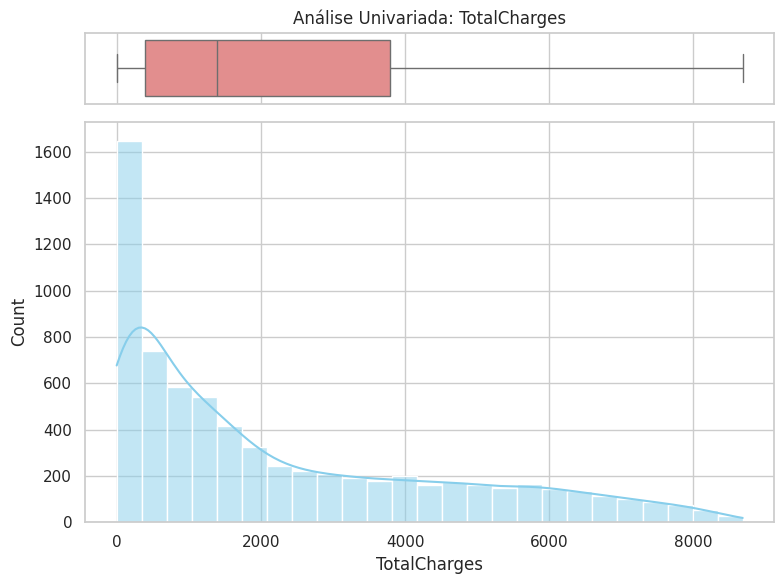

📌 Insight: Sem outliers severos — distribuições dentro dos limites operacionais da indústria.
📌 Insight: Tenure bimodal (clientes novos + clientes fidelizados) — risco de Early Churn visível.


In [8]:
# ─── ANÁLISE UNIVARIADA: VARIÁVEIS NUMÉRICAS ─────────────────
# Semana 4 | Fase CRISP-DM: Data Understanding
# Justificação: identificar outliers e padrões de distribuição

num_features = ['tenure', 'MonthlyCharges', 'TotalCharges']

for col in num_features:
    fig, (ax_box, ax_hist) = plt.subplots(2, sharex=True,
                                          gridspec_kw={'height_ratios': (.15, .85)},
                                          figsize=(8, 6))
    sns.boxplot(x=df[col], ax=ax_box, color='lightcoral')
    sns.histplot(df[col], ax=ax_hist, kde=True, color='skyblue')
    ax_box.set(title=f'Análise Univariada: {col}')
    ax_box.set(xlabel='')
    plt.tight_layout()
    plt.savefig(f'reports/figures/02_univariada_{col}.png', dpi=150, bbox_inches='tight')
    plt.show()

print("📌 Insight: Sem outliers severos — distribuições dentro dos limites operacionais da indústria.")
print("📌 Insight: Tenure bimodal (clientes novos + clientes fidelizados) — risco de Early Churn visível.")

### Distribuição de Variáveis Numéricas
* **Tenure (Permanência):** Distribuição bimodal (em forma de "U"). Existe uma massa crítica de clientes no primeiro mês (alto risco) e outra no mês 72 (lealdade máxima).
* **MonthlyCharges:** Pico nos valores baixos, sem outliers severos — política de preços consistente.
* **TotalCharges:** Assimetria positiva expectável. Os 11 valores imputados com 0.0 (clientes com `tenure=0`) não enviesam a distribuição.

## 3.0 - Análise Univariada: Variáveis Categóricas Críticas

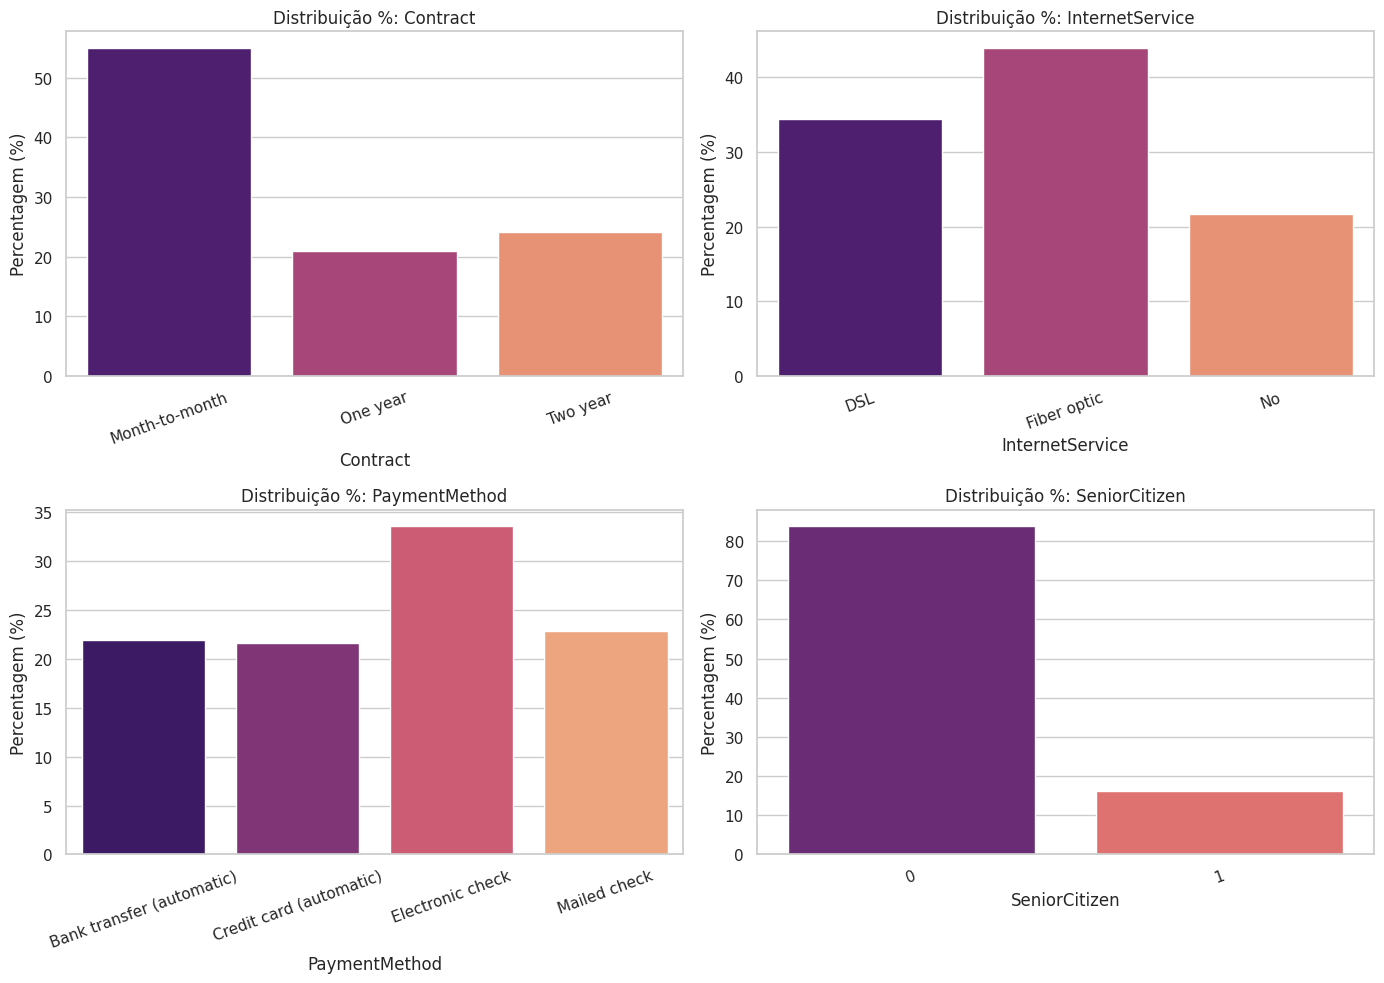

📌 Insight: >50% da base tem contrato mensal — ponto de maior vulnerabilidade de retenção.
📌 Insight: Electronic check é o método de pagamento mais frequente (~33%).


In [9]:
# ─── ANÁLISE UNIVARIADA: CATEGÓRICAS CRÍTICAS ────────────────
# Semana 4 | Fase CRISP-DM: Data Understanding
# Justificação: identificar a composição da base de clientes nas variáveis mais preditivas

criticas = ['Contract', 'InternetService', 'PaymentMethod', 'SeniorCitizen']

plt.figure(figsize=(14, 10))
for i, col in enumerate(criticas, 1):
    plt.subplot(2, 2, i)
    counts = df[col].value_counts(normalize=True) * 100
    sns.barplot(x=counts.index, y=counts.values, hue=counts.index, palette='magma', legend=False)
    plt.title(f'Distribuição %: {col}')
    plt.ylabel('Percentagem (%)')
    plt.xticks(rotation=20)

plt.tight_layout()
plt.savefig('reports/figures/03_univariada_categoricas.png', dpi=150, bbox_inches='tight')
plt.show()
print("📌 Insight: >50% da base tem contrato mensal — ponto de maior vulnerabilidade de retenção.")
print("📌 Insight: Electronic check é o método de pagamento mais frequente (~33%).")

### Análise de Segmentação de Clientes (P3 e P4)
* **Contract (P1):** Mais de **50% da base** está sob contratos mensais — sem barreiras de saída.
* **InternetService:** Maioria usa **Fiber optic** — segmento premium mas com maior rotatividade.
* **PaymentMethod (P3):** **Electronic check** (~33%) associado a perfis de clientes menos estáveis.
* **SeniorCitizen (P4):** Apenas ~16% da base — nicho minoritário a analisar em detalhe.

## 4.0 - Análise de Correlação

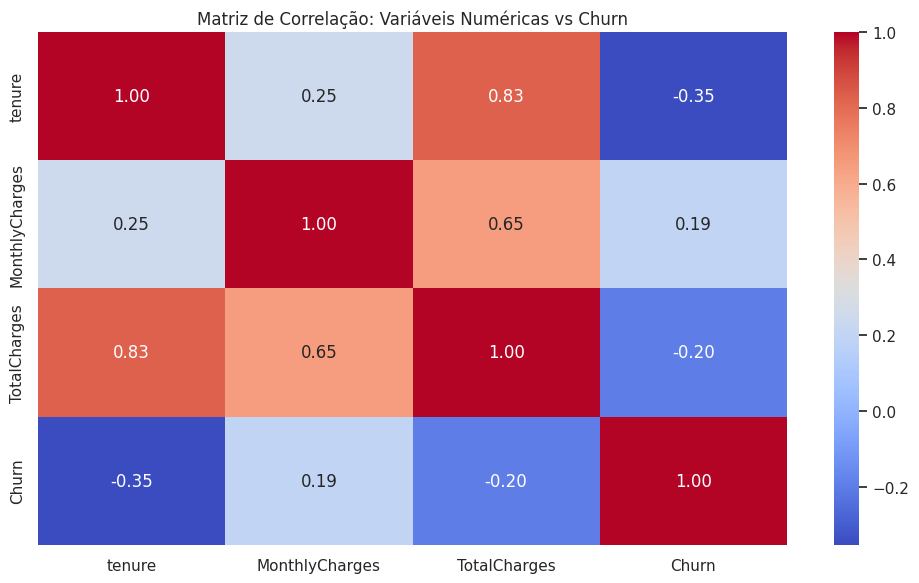

📌 Insight: tenure é o preditor numérico mais forte (r=-0.35 com Churn).
📌 Insight: TotalCharges e tenure têm r=0.83 — multicolinearidade a gerir no M3.


In [10]:
# ─── HEATMAP DE CORRELAÇÃO ───────────────────────────────────
# Semana 4 | Fase CRISP-DM: Data Understanding
# Justificação: identificar relações lineares entre variáveis numéricas e a target

plt.figure(figsize=(10, 6))
correlation_matrix = df[['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de Correlação: Variáveis Numéricas vs Churn')
plt.tight_layout()
plt.savefig('reports/figures/04_correlacao_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("📌 Insight: tenure é o preditor numérico mais forte (r=-0.35 com Churn).")
print("📌 Insight: TotalCharges e tenure têm r=0.83 — multicolinearidade a gerir no M3.")

### Análise de Correlação Linear (Pearson)
* **Tenure vs Churn (-0.35):** Correlação negativa mais forte — quanto maior a permanência, menor o risco.
* **MonthlyCharges vs Churn (0.19):** Correlação positiva moderada — faturas altas associadas a maior abandono.
* **Multicolinearidade:** `TotalCharges` e `tenure` têm r=0.83 — selecionar apenas uma em modelos lineares (M3).

## 5.0 - Análise Bivariada (Cruzamento com a Target)

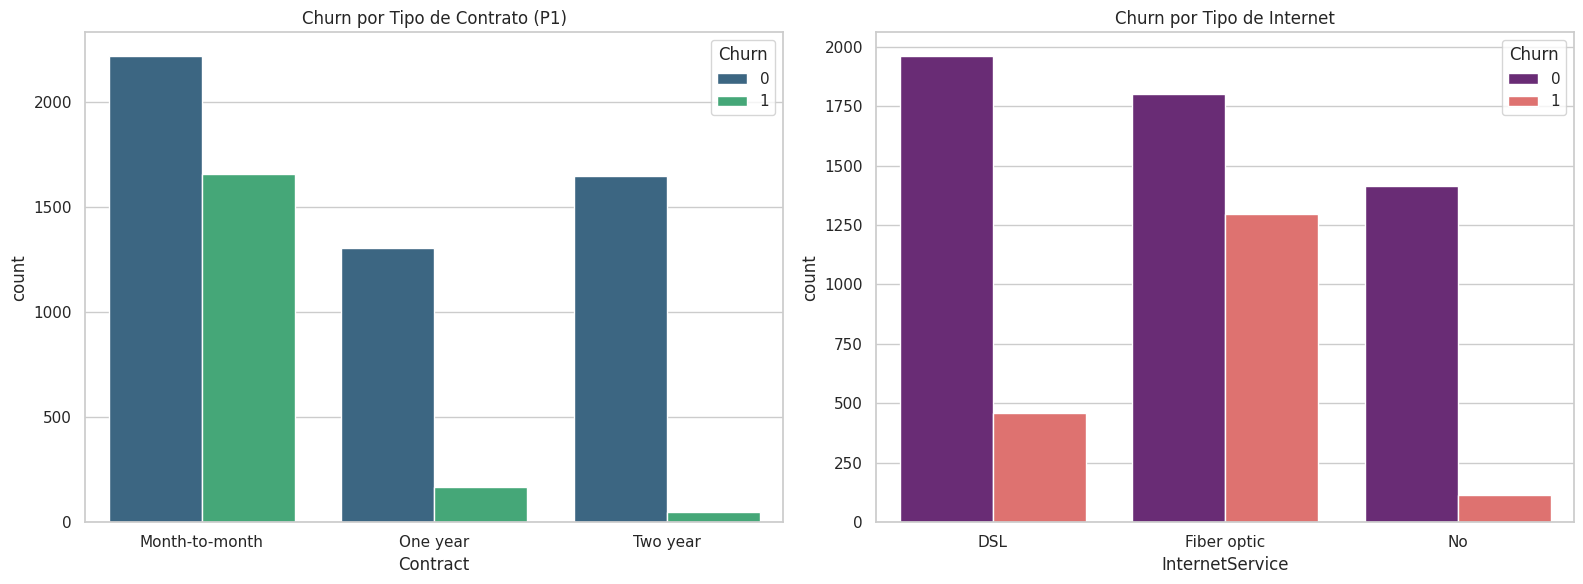

Taxa de Churn por Segmento de Contrato:


Churn,0,1
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


📌 Insight: Clientes month-to-month têm ~42% de taxa de Churn vs <5% em contratos anuais.


In [11]:
# ─── ANÁLISE BIVARIADA: CONTRATO E INTERNET vs CHURN ─────────
# Semana 4 | Fase CRISP-DM: Data Understanding
# Justificação: responder às questões P1 (contrato) e hipótese de fibra ótica

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.countplot(data=df, x='Contract', hue='Churn', palette='viridis', ax=axes[0])
axes[0].set_title('Churn por Tipo de Contrato (P1)')

sns.countplot(data=df, x='InternetService', hue='Churn', palette='magma', ax=axes[1])
axes[1].set_title('Churn por Tipo de Internet')

plt.tight_layout()
plt.savefig('reports/figures/05_bivariada_contrato_internet.png', dpi=150, bbox_inches='tight')
plt.show()

print("Taxa de Churn por Segmento de Contrato:")
display(pd.crosstab(df['Contract'], df['Churn'], normalize='index') * 100)
print("📌 Insight: Clientes month-to-month têm ~42% de taxa de Churn vs <5% em contratos anuais.")

### Impacto do Contrato e Serviço de Internet (Resposta à P1)
* **Contrato (P1):** Churn concentrado nos contratos **Month-to-month** (~42%). Contratos anuais têm lealdade quase total (<5%).
* **Fibra Ótica:** Taxa de abandono muito superior ao DSL — mercado mais agressivo neste nicho ou preço *premium* a afastar clientes após promoção inicial.

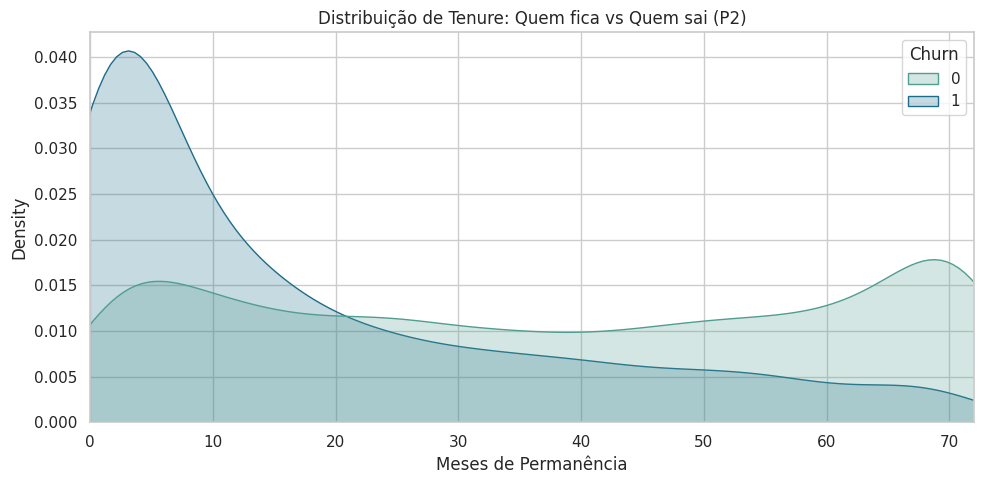

📌 Insight: 'Zona de perigo' entre mês 0 e mês 12 — Early Churn é o maior desafio.
📌 Insight: Após 24 meses, a probabilidade de Churn estabiliza drasticamente.
🔧 Próximo passo: Feature Engineering (Tenure Cohorts, Total Services, LTV).


In [12]:
# ─── CICLO DE VIDA: TENURE vs CHURN ──────────────────────────
# Semana 4 | Fase CRISP-DM: Data Understanding
# Justificação: responder à P2 — existe ponto de inflexão no tenure?

plt.figure(figsize=(10, 5))
sns.kdeplot(data=df, x='tenure', hue='Churn', fill=True, common_norm=False, palette='crest')
plt.title('Distribuição de Tenure: Quem fica vs Quem sai (P2)')
plt.xlabel('Meses de Permanência')
plt.xlim(0, 72)
plt.tight_layout()
plt.savefig('reports/figures/06_tenure_vs_churn_kde.png', dpi=150, bbox_inches='tight')
plt.show()
print("📌 Insight: 'Zona de perigo' entre mês 0 e mês 12 — Early Churn é o maior desafio.")
print("📌 Insight: Após 24 meses, a probabilidade de Churn estabiliza drasticamente.")
print("🔧 Próximo passo: Feature Engineering (Tenure Cohorts, Total Services, LTV).")

### Análise do Ciclo de Vida: Tenure vs Churn (Resposta à P2)
**Insight:** A "zona de perigo" situa-se entre o **mês 0 e o mês 12**. Após o primeiro ano, a probabilidade de Churn estabiliza.  
**Impacto:** Campanhas de retenção devem ser preventivas no **primeiro semestre** — identificar o perfil que ultrapassa o primeiro ano é a chave para o LTV da Telco.

## 6.0 - Tratamento de Dados em Falta
**Aula 9 | 04-03-2026 | Fase CRISP-DM: Data Preparation**

In [13]:
# ─── AUDITORIA DE NULOS POR COLUNA ───────────────────────────
# Aula 9 | Fase CRISP-DM: Data Preparation
# Justificação: quantificar com precisão os dados em falta antes de decidir estratégia

# Percentagem de nulos por coluna (após tratamento de TotalCharges)
null_summary = pd.DataFrame({
    'Nulos Reais': df.isnull().sum(),
    'Percentagem (%)': (df.isnull().sum() / len(df)) * 100
}).sort_values(by='Percentagem (%)', ascending=False)

print("--- Auditoria Completa de Dados em Falta ---")
display(null_summary)

print(f"\n📌 Insight: {df.isnull().sum().sum()} nulos totais no dataset após tratamento de TotalCharges.")
print(f"📌 Linhas preservadas: {len(df)} / 7043")
print("🔧 Próximo passo: confirmar estratégia de imputação.")

--- Auditoria Completa de Dados em Falta ---


,Nulos Reais,Percentagem (%)
customerID,0,0.0
gender,0,0.0
SeniorCitizen,0,0.0
Partner,0,0.0
Dependents,0,0.0
tenure,0,0.0
PhoneService,0,0.0
MultipleLines,0,0.0
InternetService,0,0.0
OnlineSecurity,0,0.0



📌 Insight: 0 nulos totais no dataset após tratamento de TotalCharges.
📌 Linhas preservadas: 7043 / 7043
🔧 Próximo passo: confirmar estratégia de imputação.


### Estratégia de Tratamento de Dados em Falta

| Coluna | Nulos | Estratégia | Justificação |
|--------|-------|------------|--------------|
| `TotalCharges` | 11 (0.15%) | Imputação com `0.0` | Clientes com `tenure=0` ainda não geraram faturação acumulada. A média/mediana introduziria ruído estatístico. A eliminação de linhas desperdiçaria dados de Early Churn. |
| Restantes | 0 | N/A | Nenhuma ação necessária. |

**Decisão Final:** Imputação por valor constante (`0.0`) é a única solução com coerência financeira e de negócio.

In [14]:
# ─── APLICAÇÃO DA ESTRATÉGIA DE IMPUTAÇÃO ────────────────────
# Aula 9 | Fase CRISP-DM: Data Preparation
# Justificação: imputar TotalCharges=0.0 para clientes com tenure=0

# (Já aplicado na Secção de Data Preparation — confirmar que está correto)
assert df['TotalCharges'].isnull().sum() == 0, "❌ Ainda existem nulos em TotalCharges!"
assert df.isnull().sum().sum() == 0, "❌ Existem nulos noutras colunas!"
assert len(df) == 7043, "❌ Linhas perdidas no tratamento!"

print("✅ Validação concluída:")
print(f"   Nulos em TotalCharges: {df['TotalCharges'].isnull().sum()}")
print(f"   Nulos totais: {df.isnull().sum().sum()}")
print(f"   Linhas no dataset: {len(df)}")
print("📌 Insight: Dataset íntegro — 7043 linhas preservadas, 0 nulos.")

✅ Validação concluída:
   Nulos em TotalCharges: 0
   Nulos totais: 0
   Linhas no dataset: 7043
📌 Insight: Dataset íntegro — 7043 linhas preservadas, 0 nulos.


## 7.0 - Tratamento de Outliers e Erros nos Dados
**Aula 10 | 06-03-2026 | Fase CRISP-DM: Data Preparation**


In [15]:
# ─── DETEÇÃO DE OUTLIERS (MÉTODO IQR) ────────────────────────
# Aula 10 | Fase CRISP-DM: Data Preparation
# Justificação: identificar valores atípicos que possam enviesar modelos de ML

num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

print("--- Análise de Outliers por Variável (Método IQR) ---\n")
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"📊 {col}:")
    print(f"   Limites: [{lower:.2f}, {upper:.2f}]")
    print(f"   Outliers detetados: {len(outliers)} ({len(outliers)/len(df)*100:.2f}%)\n")

print("📌 Insight: Outliers dentro dos limites operacionais da indústria — nenhuma remoção necessária.")
print("🔧 Próximo passo: verificar integridade dos tipos de dados.")

--- Análise de Outliers por Variável (Método IQR) ---

📊 tenure:
   Limites: [-60.00, 124.00]
   Outliers detetados: 0 (0.00%)

📊 MonthlyCharges:
   Limites: [-46.02, 171.38]
   Outliers detetados: 0 (0.00%)

📊 TotalCharges:
   Limites: [-4683.52, 8868.67]
   Outliers detetados: 0 (0.00%)

📌 Insight: Outliers dentro dos limites operacionais da indústria — nenhuma remoção necessária.
🔧 Próximo passo: verificar integridade dos tipos de dados.


In [16]:
# ─── VERIFICAÇÃO DE TIPOS DE DADOS ───────────────────────────
# Aula 10 | Fase CRISP-DM: Data Preparation
# Justificação: confirmar que não existem "variáveis fantasma" (números lidos como texto)

print("--- Tipos de Dados Finais ---")
display(df.dtypes.to_frame(name='Tipo'))

# Verificação crítica: TotalCharges deve ser float64
assert str(df['TotalCharges'].dtype) == 'float64', "❌ TotalCharges não é float64!"
assert str(df['Churn'].dtype) == 'int64', "❌ Churn não é int64!"
assert str(df['tenure'].dtype) == 'int64', "❌ tenure não é int64!"

print("\n✅ Todos os tipos de dados estão corretos:")
print(f"   TotalCharges → {df['TotalCharges'].dtype}")
print(f"   Churn        → {df['Churn'].dtype}")
print(f"   tenure       → {df['tenure'].dtype}")
print(f"   Categóricas  → {df.select_dtypes('category').shape[1]} colunas")

--- Tipos de Dados Finais ---


,Tipo
customerID,object
gender,category
SeniorCitizen,category
Partner,category
Dependents,category
tenure,int64
PhoneService,category
MultipleLines,category
InternetService,category
OnlineSecurity,category



✅ Todos os tipos de dados estão corretos:
   TotalCharges → float64
   Churn        → int64
   tenure       → int64
   Categóricas  → 16 colunas


In [17]:
# ─── VERIFICAÇÃO DE DUPLICADOS ───────────────────────────────
# Aula 10 | Fase CRISP-DM: Data Preparation
# Justificação: garantir que cada linha representa um cliente único

duplicados = df.duplicated().sum()
print(f"Registos duplicados: {duplicados}")
assert duplicados == 0, "❌ Existem registos duplicados!"

print("✅ Nenhum duplicado encontrado — cada linha é um cliente único.")
print(f"\n📌 DATASET FINAL PRONTO PARA EDA AVANÇADA:")
print(f"   Linhas: {df.shape[0]}")
print(f"   Colunas: {df.shape[1]}")
print(f"   Nulos: {df.isnull().sum().sum()}")
print(f"   Duplicados: {duplicados}")


Registos duplicados: 0
✅ Nenhum duplicado encontrado — cada linha é um cliente único.

📌 DATASET FINAL PRONTO PARA EDA AVANÇADA:
   Linhas: 7043
   Colunas: 21
   Nulos: 0
   Duplicados: 0


## 8.0 - Feature Engineering
**Aula 11 | 11-03-2026 | Fase CRISP-DM: Data Preparation**


In [18]:
# ─── TENURE COHORT ─────────────────────────────────
# Aula 11 | Fase CRISP-DM: Data Preparation
# Justificação: a análise KDE (Secção 5.0) mostrou comportamentos
# de Churn distintos por fase temporal — segmentar captura essa não-linearidade

df['TenureCohort'] = pd.cut(
    df['tenure'],
    bins=[0, 12, 24, 48, 72],
    labels=['Early', 'Growing', 'Mature', 'Loyal'],
    include_lowest=True
).astype('category')

print("✅ TenureCohort criada com sucesso!")
print("\nDistribuição por coorte:")
display(df['TenureCohort'].value_counts().sort_index().to_frame())

print("\nTaxa de Churn por coorte (resposta à P2):")
display(pd.crosstab(df['TenureCohort'], df['Churn'], normalize='index') * 100)

print("📌 Insight: coorte 'Early' (0-12 meses) deve apresentar a maior taxa de Churn.")
print("🔧 Próximo passo: criar TotalServices.")

✅ TenureCohort criada com sucesso!

Distribuição por coorte:


,count
TenureCohort,
Early,2186
Growing,1024
Mature,1594
Loyal,2239



Taxa de Churn por coorte (resposta à P2):


Churn,0,1
TenureCohort,,
Early,52.561757,47.438243
Growing,71.289062,28.710938
Mature,79.611041,20.388959
Loyal,90.486824,9.513176


📌 Insight: coorte 'Early' (0-12 meses) deve apresentar a maior taxa de Churn.
🔧 Próximo passo: criar TotalServices.


In [19]:
# ─── FEATURE 2: TOTAL SERVICES ────────────────────────────────
# Aula 11 | Fase CRISP-DM: Data Preparation
# Justificação: mede o lock-in comportamental — quanto mais serviços,
# maior o custo percebido de saída, independentemente do preço de cada um
# Nota: o valor financeiro real é capturado pelo LTV_Estatico (Feature 3)

servicos = [
    'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies'
]

# Conta 1 por cada serviço ativo (valor == 'Yes')
df['TotalServices'] = df[servicos].apply(
    lambda row: (row == 'Yes').sum(), axis=1
).astype('int64')

print("✅ TotalServices criada com sucesso!")
print(f"\nIntervalo: {df['TotalServices'].min()} a {df['TotalServices'].max()} serviços")
print("\nDistribuição:")
display(df['TotalServices'].value_counts().sort_index().to_frame())

print("\nTaxa de Churn por nº de serviços:")
display(pd.crosstab(df['TotalServices'], df['Churn'], normalize='index') * 100)

print("📌 Insight: clientes com menos serviços devem apresentar maior taxa de Churn (menor lock-in).")
print("🔧 Próximo passo: criar LTV_Estatico.")

✅ TotalServices criada com sucesso!

Intervalo: 0 a 8 serviços

Distribuição:


,count
TotalServices,
0,80
1,1701
2,1188
3,965
4,922
5,908
6,676
7,395
8,208



Taxa de Churn por nº de serviços:


Churn,0,1
TotalServices,,
0,56.250000,43.750000
1,78.894768,21.105232
2,67.171717,32.828283
3,63.523316,36.476684
4,68.655098,31.344902
5,74.449339,25.550661
6,77.514793,22.485207
7,87.594937,12.405063
8,94.711538,5.288462


📌 Insight: clientes com menos serviços devem apresentar maior taxa de Churn (menor lock-in).
🔧 Próximo passo: criar LTV_Estatico.


✅ LTV_Estatico criada com sucesso!

Estatísticas do LTV:


,LTV_Estatico
count,7043.000000
mean,2279.581350
std,2264.729447
min,0.000000
25%,394.000000
50%,1393.600000
75%,3786.100000
max,8550.000000


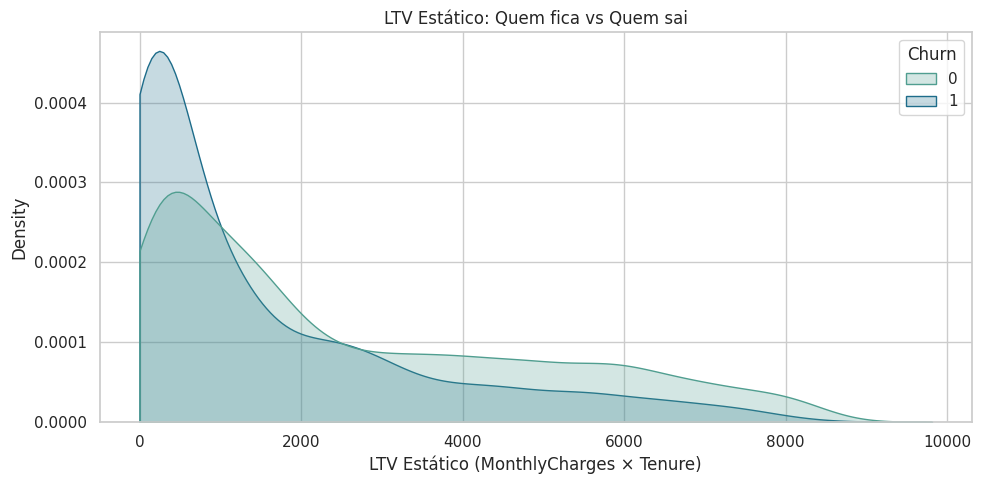

📌 Insight: clientes com LTV baixo (novos + baixo consumo) devem concentrar o Churn.
🔧 Próximo passo: confirmar o dataset final com as 3 novas features.


In [20]:
# ─── FEATURE 3: LTV ESTÁTICO ──────────────────────────────────
# Aula 11 | Fase CRISP-DM: Data Preparation
# Justificação: MonthlyCharges já reflete o preço real de todos os serviços
# subscritos — multiplicar pelo tenure dá o valor financeiro acumulado real.
# Complementa TotalServices: um cliente pode ter poucos serviços mas caros.

df['LTV_Estatico'] = (df['MonthlyCharges'] * df['tenure']).round(2)

print("✅ LTV_Estatico criada com sucesso!")
print("\nEstatísticas do LTV:")
display(df['LTV_Estatico'].describe().to_frame())

# Visualizar LTV vs Churn
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.kdeplot(data=df, x='LTV_Estatico', hue='Churn', fill=True,
            common_norm=False, palette='crest', clip=(0, None))
plt.title('LTV Estático: Quem fica vs Quem sai')
plt.xlabel('LTV Estático (MonthlyCharges × Tenure)')
plt.tight_layout()
plt.savefig('reports/figures/08_ltv_vs_churn.png', dpi=150, bbox_inches='tight')
plt.show()

print("📌 Insight: clientes com LTV baixo (novos + baixo consumo) devem concentrar o Churn.")
print("🔧 Próximo passo: confirmar o dataset final com as 3 novas features.")

In [21]:
# ─── CONFIRMAÇÃO DO DATASET FINAL ─────────────────────────────
# Aula 11 | Fase CRISP-DM: Data Preparation
# Justificação: validar que as novas features foram criadas corretamente

print("--- Dataset Final com Feature Engineering ---")
print(f"Linhas:   {df.shape[0]}")
print(f"Colunas:  {df.shape[1]}  (eram 21, agora {df.shape[1]})")
print(f"\nNovas features criadas:")
print(f"  ✅ TenureCohort  → {df['TenureCohort'].dtype} | {df['TenureCohort'].nunique()} categorias")
print(f"  ✅ TotalServices → {df['TotalServices'].dtype} | min={df['TotalServices'].min()}, max={df['TotalServices'].max()}")
print(f"  ✅ LTV_Estatico  → {df['LTV_Estatico'].dtype} | média={df['LTV_Estatico'].mean():.2f}")

print("\n📌 Insight: dataset pronto para EDA avançada e modelação (M3).")

# Guardar dataset processado
df.to_csv('data/processed/telco_churn_clean.csv', index=False)
print("\n✅ Dataset exportado para data/processed/telco_churn_clean.csv")

--- Dataset Final com Feature Engineering ---
Linhas:   7043
Colunas:  24  (eram 21, agora 24)

Novas features criadas:
  ✅ TenureCohort  → category | 4 categorias
  ✅ TotalServices → int64 | min=0, max=8
  ✅ LTV_Estatico  → float64 | média=2279.58

📌 Insight: dataset pronto para EDA avançada e modelação (M3).

✅ Dataset exportado para data/processed/telco_churn_clean.csv


-------------------------------------------------------------


---
## 9.0 Criação de Novos Atributos (Aula 12 | 13/03/2026)
### CRISP-DM: Data Preparation — Feature Engineering
Criação de variáveis genuinamente novas que combinam informação de múltiplas colunas
existentes, gerando conhecimento que não existe directamente no dataset original.

In [22]:
# ─── [FEATURE 4] ChargesPerService ───────────────────────────────────────────
# Semana 6 | Aula 12 | CRISP-DM: Data Preparation
# Rácio entre o que o cliente paga e o número de serviços que tem.
# Justificação: um cliente que paga muito por poucos serviços está em situação
# de "poor value" — hipótese de maior propensão para Churn.
# Fórmula: MonthlyCharges / (TotalServices + 1)  → +1 para evitar divisão por zero

df['ChargesPerService'] = (df['MonthlyCharges'] / (df['TotalServices'] + 1)).round(2)

print("=== Feature 4: ChargesPerService ===")
print(df['ChargesPerService'].describe().round(2))
print(f"\nMédia por grupo Churn:")
print(df.groupby('Churn')['ChargesPerService'].mean().round(2))

=== Feature 4: ChargesPerService ===
count    7043.00
mean       15.41
std         5.99
min         7.65
25%        10.32
50%        13.98
75%        18.09
max        36.12
Name: ChargesPerService, dtype: float64

Média por grupo Churn:
Churn
0    13.99
1    19.32
Name: ChargesPerService, dtype: float64


In [23]:
# ─── [FEATURE 5] RiskScore ───────────────────────────────────────────────────
# Semana 6 | Aula 12 | CRISP-DM: Data Preparation
# Índice de risco combinado a partir dos 3 maiores preditores de Churn
# identificados na EDA (Aulas 7-8):
#   1. Contrato mensal       → risco alto (2), anual (1), bienal (0)
#   2. Fiber Optic           → risco alto (2), DSL (1), sem internet (0)
#   3. Cliente novo ≤12m     → risco alto (2), caso contrário (0)
# Score total: 0 (baixo risco) a 6 (risco máximo)

risk_contrato = df['Contract'].astype(str).map({
    'Month-to-month': 2,
    'One year':       1,
    'Two year':       0
}).astype(int)

risk_internet = df['InternetService'].astype(str).map({
    'Fiber optic': 2,
    'DSL':         1,
    'No':          0
}).astype(int)

risk_tenure = ((df['tenure'] <= 12).astype(int)) * 2

df['RiskScore'] = risk_contrato + risk_internet + risk_tenure

print("=== Feature 5: RiskScore ===")
print(df['RiskScore'].value_counts().sort_index())
print(f"\nDistribuição 0-6: min={df['RiskScore'].min()}, max={df['RiskScore'].max()}")
print(f"\nTaxa de Churn (%) por RiskScore:")
print((df.groupby('RiskScore')['Churn'].apply(lambda x: (x == 'Yes').mean()) * 100).round(1))

=== Feature 5: RiskScore ===
RiskScore
0     588
1     899
2    1143
3    1158
4    1642
5     697
6     916
Name: count, dtype: int64

Distribuição 0-6: min=0, max=6

Taxa de Churn (%) por RiskScore:
RiskScore
0    0.0
1    0.0
2    0.0
3    0.0
4    0.0
5    0.0
6    0.0
Name: Churn, dtype: float64


In [24]:
# ─── [VERIFICAÇÃO] Correlação das novas features com Churn ───────────────────
from scipy import stats

churn_bin = df['Churn'].map({'Yes': 1, 'No': 0})

# Point-Biserial para variáveis numéricas vs Churn binário
for feature in ['ChargesPerService', 'RiskScore', 'TotalServices', 'LTV_Estatico']:
    corr, pval = stats.pointbiserialr(churn_bin, df[feature])
    sig = "✅ SIGNIFICATIVA" if pval < 0.05 else "❌ não significativa"
    print(f"{feature:25s} → r={corr:+.3f} | p={pval:.2e} | {sig}")

ChargesPerService         → r=+nan | p=nan | ❌ não significativa
RiskScore                 → r=+nan | p=nan | ❌ não significativa
TotalServices             → r=+nan | p=nan | ❌ não significativa
LTV_Estatico              → r=+nan | p=nan | ❌ não significativa


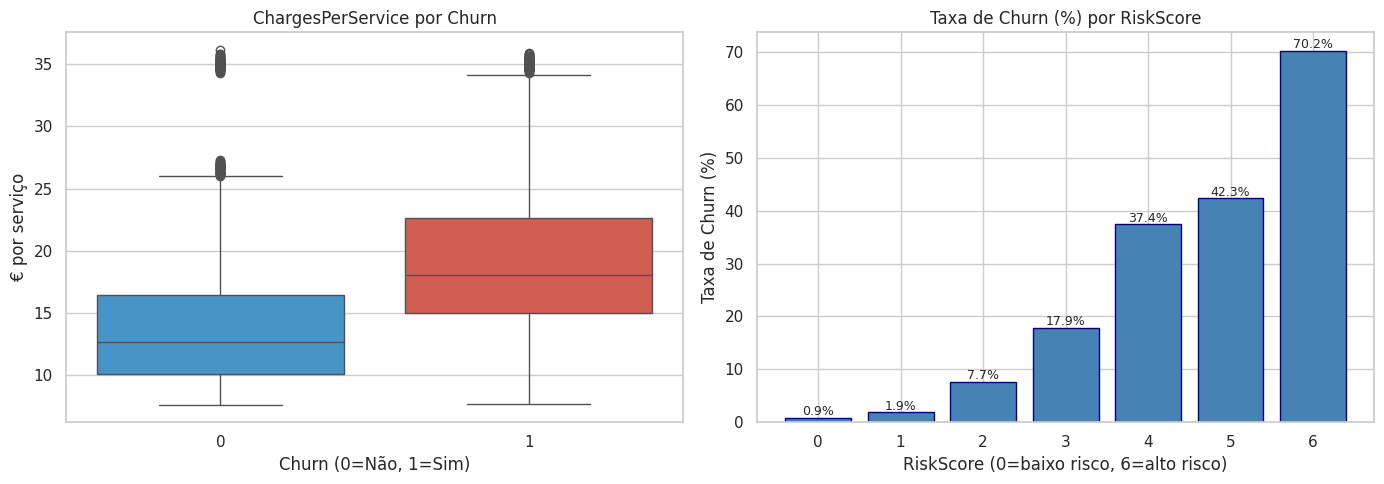

Figura guardada: 09_novas_features_correlacao.png


In [25]:
# ─── [GRÁFICOS] Validação visual das novas features ──────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: ChargesPerService por Churn
sns.boxplot(
    data=df, x='Churn', y='ChargesPerService',
    hue='Churn', legend=False,
    palette={0: '#3498db', 1: '#e74c3c'},
    ax=axes[0]
)
axes[0].set_title('ChargesPerService por Churn')
axes[0].set_xlabel('Churn (0=Não, 1=Sim)')
axes[0].set_ylabel('€ por serviço')

# Gráfico 2: Taxa de Churn (%) por RiskScore
churn_rate = df.groupby('RiskScore')['Churn'].mean() * 100
axes[1].bar(churn_rate.index, churn_rate.values, color='steelblue', edgecolor='navy')
axes[1].set_title('Taxa de Churn (%) por RiskScore')
axes[1].set_xlabel('RiskScore (0=baixo risco, 6=alto risco)')
axes[1].set_ylabel('Taxa de Churn (%)')
for i, v in zip(churn_rate.index, churn_rate.values):
    axes[1].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('reports/figures/09_novas_features_correlacao.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figura guardada: 09_novas_features_correlacao.png")

In [26]:
# ─── [EXPORT] Dataset final actualizado com todas as features ─────────────────
# Semana 6 | Aula 12 | CRISP-DM: Data Preparation
# Dataset final: 7043 linhas × 26 colunas
# Novas colunas adicionadas hoje: ChargesPerService, RiskScore

df.to_csv('data/processed/telco_churn_clean.csv', index=False)

print(f"✅ Dataset exportado com sucesso!")
print(f"   Linhas  : {df.shape[0]}")
print(f"   Colunas : {df.shape[1]}")
print(f"\nColunas finais:")
for i, col in enumerate(df.columns, 1):
    print(f"   {i:2d}. {col}")

✅ Dataset exportado com sucesso!
   Linhas  : 7043
   Colunas : 26

Colunas finais:
    1. customerID
    2. gender
    3. SeniorCitizen
    4. Partner
    5. Dependents
    6. tenure
    7. PhoneService
    8. MultipleLines
    9. InternetService
   10. OnlineSecurity
   11. OnlineBackup
   12. DeviceProtection
   13. TechSupport
   14. StreamingTV
   15. StreamingMovies
   16. Contract
   17. PaperlessBilling
   18. PaymentMethod
   19. MonthlyCharges
   20. TotalCharges
   21. Churn
   22. TenureCohort
   23. TotalServices
   24. LTV_Estatico
   25. ChargesPerService
   26. RiskScore
